<a href="https://colab.research.google.com/github/NehaSajjanar23/6thSem-ML-Lab/blob/main/1BM23CS209_LabExam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('/content/Mall_Customers.csv')


print("First 5 rows of the dataset:")
display(df.head())


print("\nInformation about the dataset:")
display(df.info())

First 5 rows of the dataset:


,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

In [25]:
# Check for missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())


Missing values in each column:
CustomerID            0
Genre                 0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64


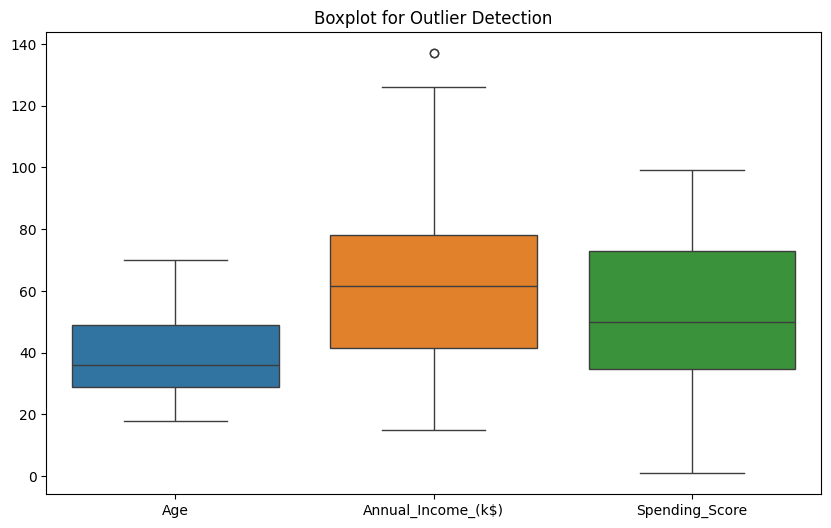

In [27]:
# Select numerical columns for outlier detection
numerical_cols = ['Age', 'Annual_Income_(k$)', 'Spending_Score']

# Plot boxplots to visualize outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[numerical_cols])
plt.title("Boxplot for Outlier Detection")
plt.show()

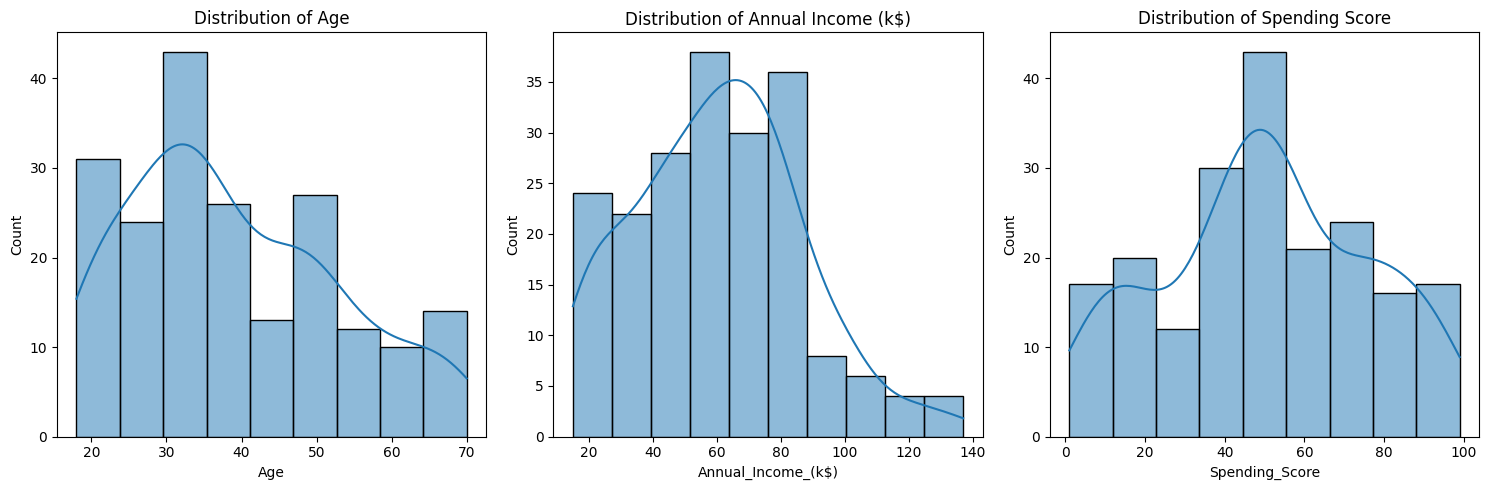

In [12]:
import seaborn as sns
# Visualize the distribution of 'Age', 'Annual_Income_(k$)', and 'Spending_Score'
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df['Annual_Income_(k$)'], kde=True)
plt.title('Distribution of Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.histplot(df['Spending_Score'], kde=True)
plt.title('Distribution of Spending Score')

plt.tight_layout()
plt.show()

In [15]:
# Create a new target variable for high/low spending
# We'll use the median Spending_Score as a threshold to define 'high' and 'low'
median_spending_score = df['Spending_Score'].median()
df['High_Spending'] = (df['Spending_Score'] > median_spending_score).astype(int)

print(f"Median Spending Score: {median_spending_score}")
print("Distribution of High_Spending target variable:")
display(df['High_Spending'].value_counts())

# Define features (X) and the new target (y)
X_spending = df[['Age', 'Annual_Income_(k$)']]
y_spending = df['High_Spending']

# Split the dataset for the new task
X_train_spending, X_test_spending, y_train_spending, y_test_spending = train_test_split(
    X_spending, y_spending, test_size=0.3, random_state=42, stratify=y_spending # Stratify to maintain class balance
)

# Train a RandomForestClassifier
rf_spending = RandomForestClassifier(n_estimators=100, random_state=42)
rf_spending.fit(X_train_spending, y_train_spending)

# Make predictions and evaluate the model
y_pred_spending = rf_spending.predict(X_test_spending)

print("\n--- High/Low Spending Classification ---")
print("Accuracy:", accuracy_score(y_test_spending, y_pred_spending))
print("Confusion Matrix:\n", confusion_matrix(y_test_spending, y_pred_spending))

Median Spending Score: 50.0
Distribution of High_Spending target variable:


,count
High_Spending,
0,103
1,97



--- High/Low Spending Classification ---
Accuracy: 0.5333333333333333
Confusion Matrix:
 [[14 17]
 [11 18]]


In [17]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# Check data
print(df.head())

# Features and target
# Use 'Genre' as the target variable and encode it
le = LabelEncoder()
df['Genre_Encoded'] = le.fit_transform(df['Genre'])

X = df.drop(['CustomerID', 'Genre', 'Genre_Encoded'], axis=1) # Drop original Genre and CustomerID
y = df['Genre_Encoded'] # Use the encoded Genre as target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -------------------------------
# Default Random Forest (10 trees)
# -------------------------------
rf_default = RandomForestClassifier(n_estimators=10, random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

print("\nDefault Model (10 Trees)")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_default))

# -------------------------------
# Fine-tuning n_estimators
# -------------------------------
best_acc = 0
best_trees = 0
best_cm = None

for trees in [5, 10, 20, 50, 100, 150, 200]:
    rf = RandomForestClassifier(n_estimators=trees, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Trees: {trees}, Accuracy: {acc}")

    if acc > best_acc:
        best_acc = acc
        best_trees = trees
        best_cm = confusion_matrix(y_test, y_pred)

# Best result
print("\nBest Result")
print("Best Number of Trees:", best_trees)
print("Best Accuracy:", best_acc)
print("Confusion Matrix:\n", best_cm)

   CustomerID   Genre  Age  Annual_Income_(k$)  Spending_Score
0           1    Male   19                  15              39
1           2    Male   21                  15              81
2           3  Female   20                  16               6
3           4  Female   23                  16              77
4           5  Female   31                  17              40

Default Model (10 Trees)
Accuracy: 0.6166666666666667
Confusion Matrix:
 [[28  8]
 [15  9]]
Trees: 5, Accuracy: 0.6
Trees: 10, Accuracy: 0.6166666666666667
Trees: 20, Accuracy: 0.55
Trees: 50, Accuracy: 0.5833333333333334
Trees: 100, Accuracy: 0.6
Trees: 150, Accuracy: 0.6
Trees: 200, Accuracy: 0.6

Best Result
Best Number of Trees: 10
Best Accuracy: 0.6166666666666667
Confusion Matrix:
 [[28  8]
 [15  9]]


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')

# Preview the data
print(df.head())


   CustomerID   Genre  Age  Annual_Income_(k$)  Spending_Score
0           1    Male   19                  15              39
1           2    Male   21                  15              81
2           3  Female   20                  16               6
3           4  Female   23                  16              77
4           5  Female   31                  17              40


In [34]:
# Handle missing values (if any)
df = df.dropna()  # Alternatively, you could use df.fillna() for filling

# Select features for clustering
X = df[['Annual_Income_(k$)', 'Spending_Score']]

# Feature scaling using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Check the scaled features
print(X_scaled[:5])


[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


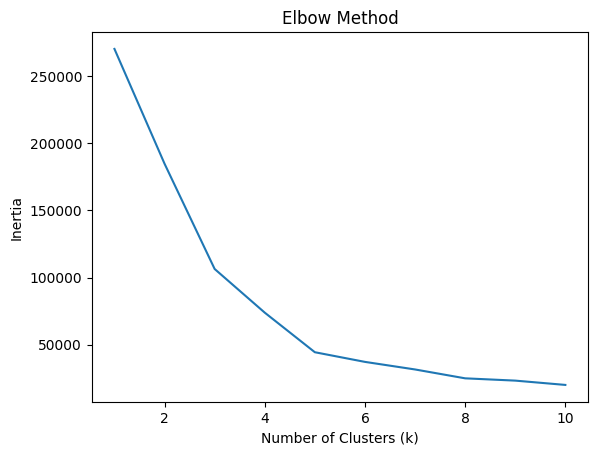

In [35]:
from sklearn.cluster import KMeans

# Elbow Method to find optimal k
inertia = []
for k in range(1, 11):  # Checking for k between 1 and 10
    kmeans = KMeans(n_clusters=k, random_state=10)
    kmeans.fit(X)

    inertia.append(kmeans.inertia_)

# Plot the elbow graph
plt.plot(range(1, 11), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()


In [36]:
# Apply K-means with the chosen number of clusters (e.g., k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Preview the data with cluster labels
print(df.head())

   CustomerID   Genre  Age  Annual_Income_(k$)  Spending_Score  Cluster
0           1    Male   19                  15              39        2
1           2    Male   21                  15              81        2
2           3  Female   20                  16               6        2
3           4  Female   23                  16              77        2
4           5  Female   31                  17              40        2


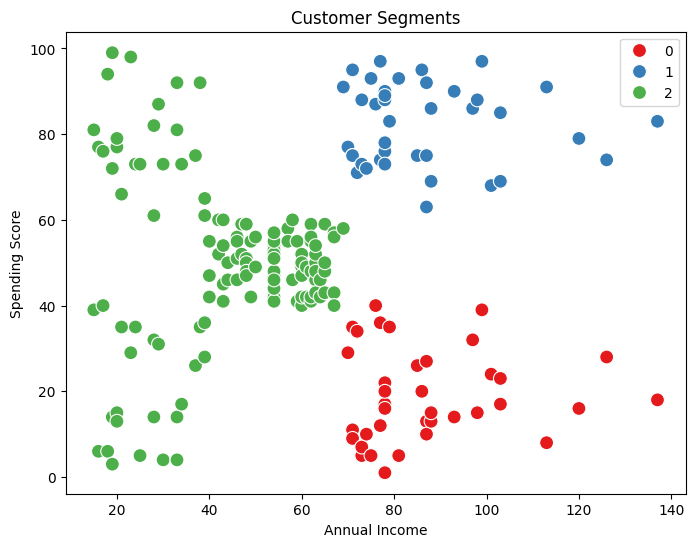

In [37]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Annual_Income_(k$)'], y=df['Spending_Score'], hue=df['Cluster'], palette='Set1', s=100)
plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [38]:
from sklearn.metrics import silhouette_score

# Assuming you chose the optimal k (e.g., k=3) from your elbow plot
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(X)

# Calculate Silhouette Score
score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.4f}")


Silhouette Score: 0.4676


In [21]:
# Initialize and train an SVM classifier for High/Low Spending
svm_spending = SVC(random_state=42)
svm_spending.fit(X_train_spending, y_train_spending)

# Make predictions
y_pred_svm_spending = svm_spending.predict(X_test_spending)

print("--- SVM High/Low Spending Classification ---")
print("Accuracy:", accuracy_score(y_test_spending, y_pred_svm_spending))
print("Confusion Matrix:\n", confusion_matrix(y_test_spending, y_pred_svm_spending))

# Optionally, fine-tune SVM for spending as well (similar to genre classification)
print("\n--- Fine-tuning SVM for High/Low Spending ---")
best_acc_svm_spending = 0
best_params_svm_spending = {}
best_cm_svm_spending = None

for c in C_values:
    for kernel in kernels:
        svm_tuned_spending = SVC(C=c, kernel=kernel, random_state=42)
        svm_tuned_spending.fit(X_train_spending, y_train_spending)

        y_pred_tuned_svm_spending = svm_tuned_spending.predict(X_test_spending)
        acc_svm_spending = accuracy_score(y_test_spending, y_pred_tuned_svm_spending)

        print(f"C: {c}, Kernel: {kernel}, Accuracy: {acc_svm_spending}")

        if acc_svm_spending > best_acc_svm_spending:
            best_acc_svm_spending = acc_svm_spending
            best_params_svm_spending = {'C': c, 'kernel': kernel}
            best_cm_svm_spending = confusion_matrix(y_test_spending, y_pred_tuned_svm_spending)

print("\nBest SVM Result for High/Low Spending")
print("Best Parameters:", best_params_svm_spending)
print("Best Accuracy:", best_acc_svm_spending)
print("Confusion Matrix:\n", best_cm_svm_spending)

--- SVM High/Low Spending Classification ---
Accuracy: 0.5833333333333334
Confusion Matrix:
 [[14 17]
 [ 8 21]]

--- Fine-tuning SVM for High/Low Spending ---
C: 0.1, Kernel: linear, Accuracy: 0.65
C: 0.1, Kernel: rbf, Accuracy: 0.5166666666666667
C: 0.1, Kernel: poly, Accuracy: 0.6166666666666667
C: 1, Kernel: linear, Accuracy: 0.65
C: 1, Kernel: rbf, Accuracy: 0.5833333333333334
C: 1, Kernel: poly, Accuracy: 0.6
C: 10, Kernel: linear, Accuracy: 0.65
C: 10, Kernel: rbf, Accuracy: 0.65
C: 10, Kernel: poly, Accuracy: 0.6
C: 100, Kernel: linear, Accuracy: 0.65
C: 100, Kernel: rbf, Accuracy: 0.6833333333333333
C: 100, Kernel: poly, Accuracy: 0.6

Best SVM Result for High/Low Spending
Best Parameters: {'C': 100, 'kernel': 'rbf'}
Best Accuracy: 0.6833333333333333
Confusion Matrix:
 [[18 13]
 [ 6 23]]
